In [1]:
import pandas as pd      
import geopandas as gpd  
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import os

In [2]:
# Configuración de rutas (Ajusta según tu estructura)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
GEOFILES_DIR = os.path.join(DATA_DIR, "geofiles")
REZAGO_DIR = os.path.join(DATA_DIR, "rezago_social")

# Rutas específicas
ruta_municipios = os.path.join(GEOFILES_DIR, "nacional", "MUNICIPIOS.shp")
ruta_disponibilidad = os.path.join(GEOFILES_DIR, "disponibilidad_de_agua_subterranea_09-11-2023.shp")
ruta_rezago = os.path.join(REZAGO_DIR, "IRS_localidades_2020.xlsx")

In [31]:
# Cargar mapas
gdf_mun = gpd.read_file(ruta_municipios)
gdf_disp = gpd.read_file(ruta_disponibilidad)

# Crear clave de 5 dígitos (CVE_ENT + CVE_MUN) para el mapa de municipios
# zfill(x) asegura que siempre tenga ceros a la izquierda (ej: '9' -> '09')
gdf_mun['cve_geo_mun'] = gdf_mun['CVE_ENT'].astype(str).str.zfill(2) + \
                         gdf_mun['CVE_MUN'].astype(str).str.zfill(3)

print(f"Mapas cargados. Total de municipios en mapa: {len(gdf_mun)}")

Mapas cargados. Total de municipios en mapa: 2456


In [45]:
hojas = ['Localidades AGS-MICH', 'Localidades MOR-ZAC']
lista_df = []

print("Iniciando lectura de datos de CONEVAL...")

for hoja in hojas:
    print(f"-> Procesando hoja: {hoja}...")
    
    # Leemos sin encabezado para detectar las posiciones reales (header=None)
    df_temp = pd.read_excel(ruta_rezago, sheet_name=hoja, header=None)
    
    # Según tu captura de Excel:
    # Columna B es 'Clave localidad' -> Índice 1
    # Columna D es 'Municipio'       -> Índice 3
    # Columna O es 'Índice de rezago' -> Índice 14 (o la 15ava columna)
    
    # 1. Seleccionamos las columnas por número de posición
    df_temp = df_temp[[1, 3, 14]] 
    
    # 2. Renombramos para trabajar fácil
    df_temp.columns = ['cve_loc', 'mun_name', 'rezago']
    
    # 3. Limpiamos: Nos quedamos solo con las filas donde la clave sea un número real
    # Esto elimina automáticamente los títulos, logos y filas vacías (filas 0 a 7)
    df_temp = df_temp[pd.to_numeric(df_temp['cve_loc'], errors='coerce').notnull()].copy()
    
    lista_df.append(df_temp)

# Unir las pestañas
df_rezago_raw = pd.concat(lista_df, ignore_index=True)

# 4. Limpieza de Clave: Asegurar 9 dígitos y extraer los primeros 5 para el Municipio
df_rezago_raw['cve_loc_str'] = df_rezago_raw['cve_loc'].astype(float).astype(int).astype(str).str.zfill(9)
df_rezago_raw['cve_geo_mun'] = df_rezago_raw['cve_loc_str'].str[:5]

# 5. Asegurar que el rezago sea número
df_rezago_raw['rezago'] = pd.to_numeric(df_rezago_raw['rezago'], errors='coerce')

# 6. Agrupar por municipio (Promedio municipal)
df_rezago_final = df_rezago_raw.groupby('cve_geo_mun').agg({
    'mun_name': 'first',
    'rezago': 'mean'
}).reset_index()

# Renombrar columna para que la Celda 5 la encuentre igual que antes
df_rezago_final = df_rezago_final.rename(columns={'rezago': 'Índice de rezago social'})

print(f"¡Proceso completado! Municipios encontrados: {len(df_rezago_final)}")
display(df_rezago_final.head())

Iniciando lectura de datos de CONEVAL...
-> Procesando hoja: Localidades AGS-MICH...
-> Procesando hoja: Localidades MOR-ZAC...
¡Proceso completado! Municipios encontrados: 2469


,cve_geo_mun,mun_name,Índice de rezago social
0,01001,Aguascalientes,7.994488
1,01002,Asientos,9.956953
2,01003,Calvillo,4.846338
3,01004,Cosío,3.976508
4,01005,Jesús María,5.046263


In [47]:
# 1. Igualar sistemas de coordenadas
gdf_disp = gdf_disp.to_crs(gdf_mun.crs)

# 2. Cruce espacial para asignar datos de acuíferos a cada municipio
# Un municipio puede estar sobre varios acuíferos; tomamos el peor escenario de déficit
gdf_unido_hidrico = gpd.sjoin(gdf_mun, gdf_disp, how="left", predicate="intersects")

# 3. Agrupar para que no haya repetidos por municipio, tomando el valor mínimo de DMA_NEGATI
df_hidrico_final = gdf_unido_hidrico.groupby('cve_geo_mun').agg({
    'NOM_MUN': 'first',
    'DMA_NEGATI': 'min',  # El déficit más alto
    'RECARGA_TO': 'mean',
    'geometry': 'first'
}).reset_index()

# Convertir de nuevo a GeoDataFrame
gdf_hidrico_final = gpd.GeoDataFrame(df_hidrico_final, geometry='geometry', crs=gdf_mun.crs)

print("Cruce hídrico completado.")

Cruce hídrico completado.


Realizando unión con el mapa hídrico...
Unión exitosa. Municipios en el mapa: 2456


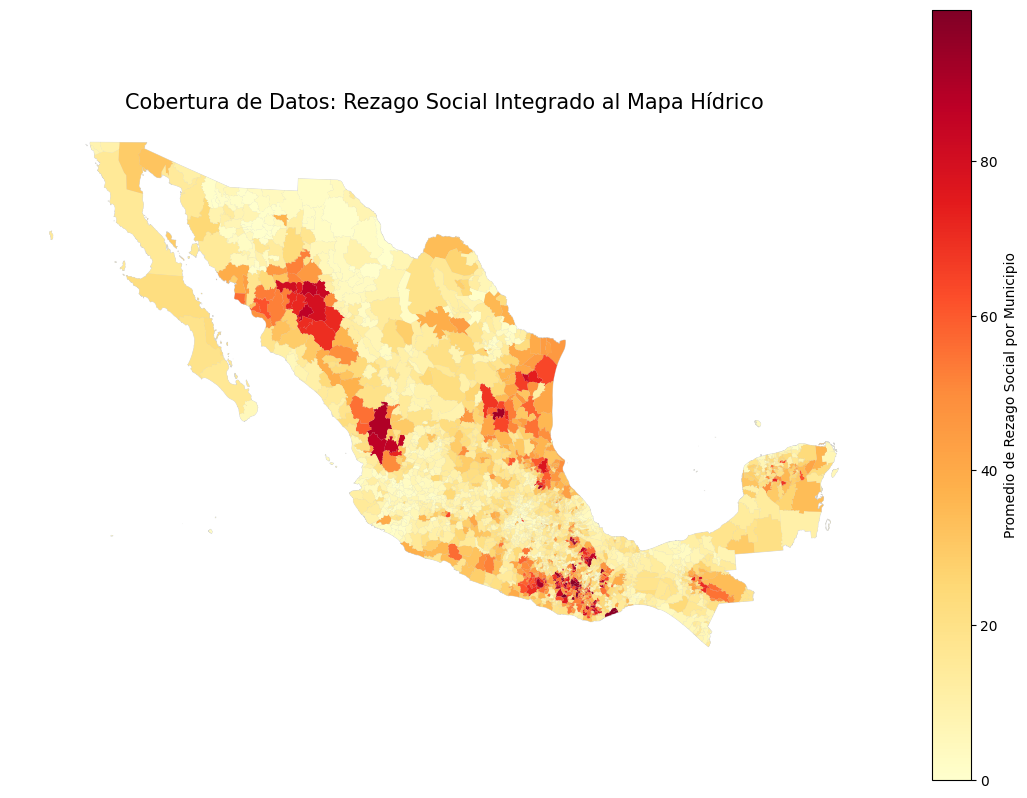

In [48]:
print("Realizando unión con el mapa hídrico...")

# Unión final por clave numérica de 5 dígitos
final_vulnerabilidad = pd.merge(
    gdf_hidrico_final, 
    df_rezago_final[['cve_geo_mun', 'Índice de rezago social']], 
    on='cve_geo_mun', 
    how='inner'
)

if final_vulnerabilidad.empty:
    print("ADVERTENCIA: La unión sigue vacía.")
    # Diagnóstico rápido de claves
    print(f"Clave Mapa (ej): {gdf_hidrico_final['cve_geo_mun'].iloc[0]}")
    print(f"Clave Excel (ej): {df_rezago_final['cve_geo_mun'].iloc[0]}")
else:
    print(f"Unión exitosa. Municipios en el mapa: {len(final_vulnerabilidad)}")
    
    # Visualización
    fig, ax = plt.subplots(figsize=(14, 10))
    # Dibujamos todo México de fondo
    gdf_mun.plot(ax=ax, color='#f2f2f2', edgecolor='#d1d1d1', linewidth=0.5)
    
    # Dibujamos los datos (coloreando por rezago social)
    final_vulnerabilidad.plot(
        ax=ax, 
        column='Índice de rezago social', 
        cmap='YlOrRd', 
        legend=True,
        legend_kwds={'label': "Promedio de Rezago Social por Municipio"}
    )
    
    plt.title("Cobertura de Datos: Rezago Social Integrado al Mapa Hídrico", fontsize=15)
    plt.axis('off')
    plt.show()

In [49]:
# 1. Normalizar las variables para que estén en la misma escala (0 a 1)
# Para el déficit, invertimos la escala: más negativo = más vulnerabilidad
final_vulnerabilidad['norm_deficit'] = (final_vulnerabilidad['DMA_NEGATI'] - final_vulnerabilidad['DMA_NEGATI'].max()) / \
                                       (final_vulnerabilidad['DMA_NEGATI'].min() - final_vulnerabilidad['DMA_NEGATI'].max())

final_vulnerabilidad['norm_rezago'] = (final_vulnerabilidad['Índice de rezago social'] - final_vulnerabilidad['Índice de rezago social'].min()) / \
                                      (final_vulnerabilidad['Índice de rezago social'].max() - final_vulnerabilidad['Índice de rezago social'].min())

# 2. Crear el Índice de Vulnerabilidad Combinada (50% agua, 50% social)
final_vulnerabilidad['prioridad_ods6'] = (final_vulnerabilidad['norm_deficit'] + final_vulnerabilidad['norm_rezago']) / 2

print("Índice de prioridad calculado.")
display(final_vulnerabilidad[['NOM_MUN', 'DMA_NEGATI', 'Índice de rezago social', 'prioridad_ods6']].sort_values(by='prioridad_ods6', ascending=False).head(10))

Índice de prioridad calculado.


,NOM_MUN,DMA_NEGATI,Índice de rezago social,prioridad_ods6
713,Nezahualcóyotl,-480.429914,66.677643,0.793686
273,Álvaro Obregón,-480.429914,36.127318,0.640347
1942,San Luis Río Colorado,-432.044272,31.818561,0.572492
12,Mexicali,-432.044272,28.945835,0.558073
675,Coacalco de Berriozábal,-480.429914,18.341147,0.551075
199,Aldama,-523.325232,9.234475,0.546350
208,Camargo,-523.325232,7.926900,0.539787
239,Manuel Benavides,-523.325232,7.193516,0.536106
759,Tlalnepantla de Baz,-480.429914,15.043017,0.534521
705,Juchitepec,-480.429914,14.552909,0.532061


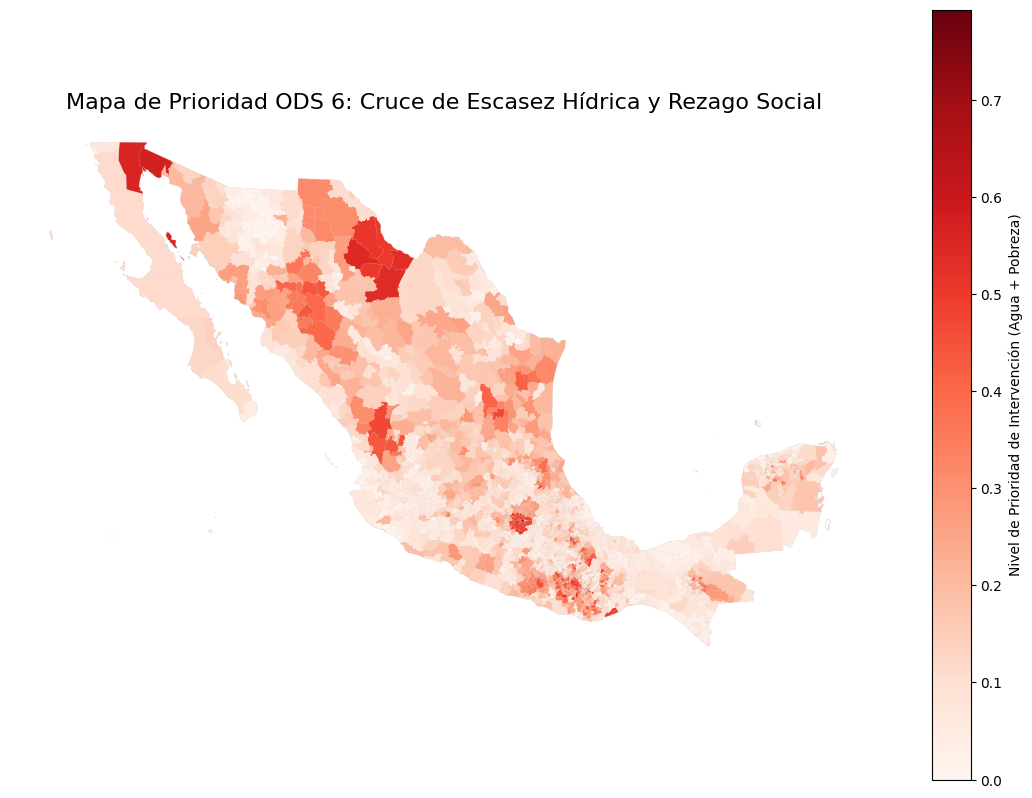

In [50]:
fig, ax = plt.subplots(figsize=(14, 10))

# Fondo gris para municipios sin datos
gdf_mun.plot(ax=ax, color='#f2f2f2', edgecolor='#d1d1d1', linewidth=0.3)

# Mapa de calor de prioridad
final_vulnerabilidad.plot(
    ax=ax, 
    column='prioridad_ods6', 
    cmap='Reds', 
    legend=True,
    legend_kwds={'label': "Nivel de Prioridad de Intervención (Agua + Pobreza)"},
    missing_kwds={'color': 'lightgrey'}
)

plt.title("Mapa de Prioridad ODS 6: Cruce de Escasez Hídrica y Rezago Social", fontsize=16)
plt.axis('off')
plt.show()

In [51]:
top_20_criticos = final_vulnerabilidad.sort_values(by='prioridad_ods6', ascending=False).head(20)

print("--- TOP 20 MUNICIPIOS DE ATENCIÓN PRIORITARIA ---")
print(top_20_criticos[['NOM_MUN', 'Índice de rezago social', 'DMA_NEGATI']].to_string(index=False))

# Guardar este reporte en la carpeta de resultados
output_path = os.path.join(DATA_DIR, "processed", "municipios_criticos_ods6.csv")
top_20_criticos.to_csv(output_path, index=False)
print(f"\nLista guardada en: {output_path}")

--- TOP 20 MUNICIPIOS DE ATENCIÓN PRIORITARIA ---
                NOM_MUN  Índice de rezago social  DMA_NEGATI
         Nezahualcóyotl                66.677643 -480.429914
         Álvaro Obregón                36.127318 -480.429914
  San Luis Río Colorado                31.818561 -432.044272
               Mexicali                28.945835 -432.044272
Coacalco de Berriozábal                18.341147 -480.429914
                 Aldama                 9.234475 -523.325232
                Camargo                 7.926900 -523.325232
       Manuel Benavides                 7.193516 -523.325232
    Tlalnepantla de Baz                15.043017 -480.429914
             Juchitepec                14.552909 -480.429914
           Tlalnepantla                11.452653 -480.429914
       Coyame del Sotol                 2.218935 -523.325232
     Santiago Amoltepec                99.617302   -8.654666
              Tepoztlán                 9.729147 -480.429914
 La Magdalena Contreras            

In [53]:
import os

# Definir rutas
processed_dir = os.path.join(DATA_DIR, "processed")
ruta_final_csv = os.path.join(processed_dir, "vulnerabilidad_maestra_ods6.csv")
ruta_final_geojson = os.path.join(processed_dir, "vulnerabilidad_maestra_ods6.geojson")

# Guardar como CSV
df_para_csv = final_vulnerabilidad.drop(columns='geometry')
df_para_csv.to_csv(ruta_final_csv, index=False, encoding='utf-8-sig')

# Guardar como GeoJSON
final_vulnerabilidad.to_file(ruta_final_geojson, driver='GeoJSON')

print(f"--- DATOS ACTUALIZADOS ---")
print(f"Archivo CSV guardado (para Excel/Reportes): {ruta_final_csv}")
print(f"Archivo GeoJSON guardado (para Mapas): {ruta_final_geojson}")

--- DATOS ACTUALIZADOS ---
Archivo CSV guardado (para Excel/Reportes): C:\Users\Jafet\agua_vulnerabilidad_ods\data\processed\vulnerabilidad_maestra_ods6.csv
Archivo GeoJSON guardado (para Mapas): C:\Users\Jafet\agua_vulnerabilidad_ods\data\processed\vulnerabilidad_maestra_ods6.geojson


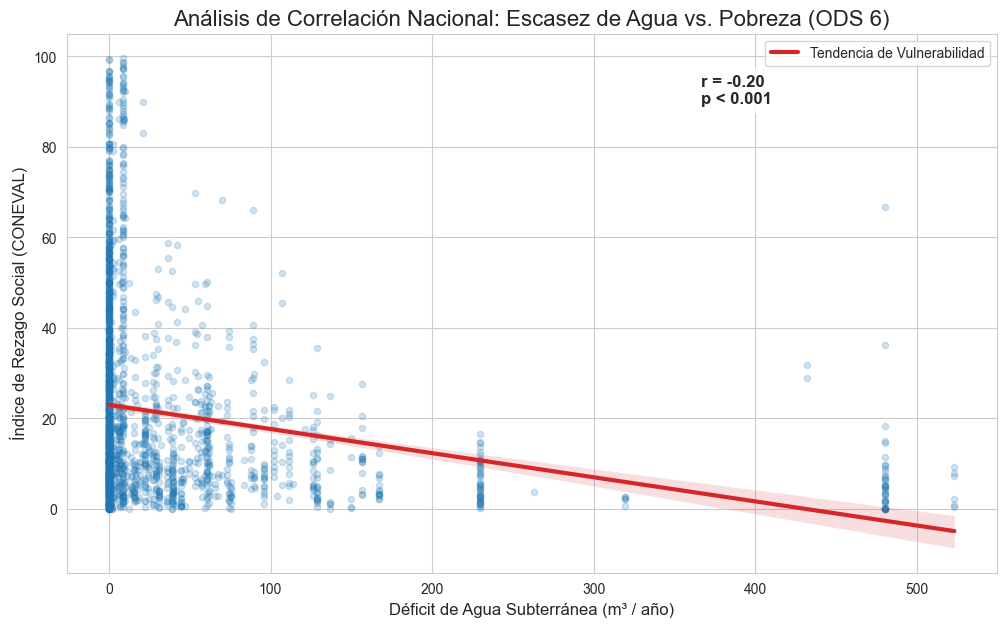

In [5]:
# 1. Carga
ruta_maestra = os.path.join(DATA_DIR, "processed", "vulnerabilidad_maestra_ods6.csv")
df_plot = pd.read_csv(ruta_maestra)

# 2. Configuración
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Crear el Scatter Plot con Línea de Regresión
# Usamos el valor absoluto del déficit para que a la derecha esté "más escasez"
x_data = df_plot['DMA_NEGATI'].abs()
y_data = df_plot['Índice de rezago social']

plot = sns.regplot(
    x=x_data, 
    y=y_data,
    scatter_kws={'alpha':0.2, 'color':'#1f77b4', 's':20},
    line_kws={'color':'#d62728', 'lw':3, 'label':'Tendencia de Vulnerabilidad'}
)

# 4. Anotación estadística en la gráfica
corr, p_val = stats.pearsonr(x_data.dropna(), y_data.dropna())
plt.text(x_data.max()*0.7, y_data.max()*0.9, f'r = {corr:.2f}\np < 0.001', 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12, fontweight='bold')

plt.title("Análisis de Correlación Nacional: Escasez de Agua vs. Pobreza (ODS 6)", fontsize=16)
plt.xlabel("Déficit de Agua Subterránea (m³ / año)", fontsize=12)
plt.ylabel("Índice de Rezago Social (CONEVAL)", fontsize=12)
plt.legend()

plt.show()